In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
archivo = "Datos caudales.xlsx"

raw = pd.read_excel(archivo, sheet_name="Hoja1", header=None)

filas_casos = raw.index[
    raw[0].astype(str).str.contains("Caso", case=False, na=False)
].tolist()

dfs = {}

for i, fila_inicio in enumerate(filas_casos):

    nombre_caso = raw.loc[fila_inicio, 0]

    if i < len(filas_casos) - 1:
        fila_fin = filas_casos[i + 1]
    else:
        fila_fin = len(raw)

    df_temp = raw.iloc[fila_inicio + 1:fila_fin, [1, 2]].copy()

    df_temp.columns = ["P_bar", "Q_L_hr"]

    df_temp = df_temp.dropna(how="all")

    df_temp["P_bar"] = pd.to_numeric(df_temp["P_bar"], errors="coerce")
    df_temp["Q_L_hr"] = pd.to_numeric(df_temp["Q_L_hr"], errors="coerce")

    df_temp = df_temp.dropna(subset=["P_bar", "Q_L_hr"])

    df_temp = df_temp.reset_index(drop=True)

    dfs[nombre_caso] = df_temp

df_caso1 = dfs["Caso 1"]
df_caso2 = dfs["Caso 2"]
df_caso3 = dfs["Caso 3"]

Coeficientes caso 1:
a = -0.0014876302896472918
b = -0.05888067852226272
c = 32.631690895060714

Ecuación ajustada:
H(Q) = -0.001488 Q^2 + -0.058881 Q + 32.631691
R2 = 0.9698


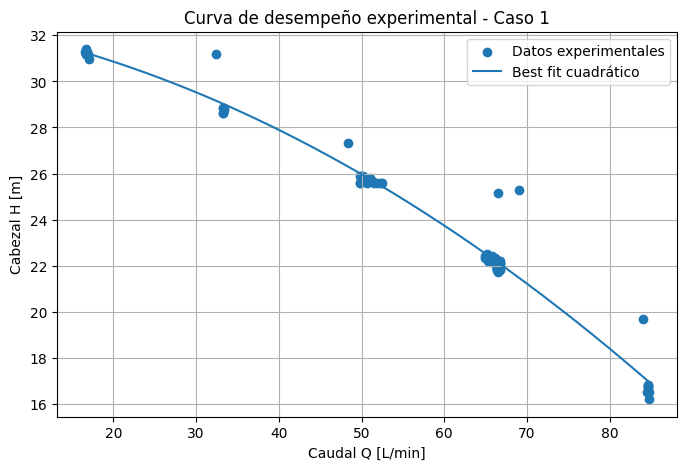

In [4]:
rho = 1000
g = 9.81

P_salida_bar = df_caso1["P_bar"]
P_salida_Pa_1 = P_salida_bar * 100000

Q_L_min_1 = df_caso1["Q_L_hr"] / 60

H_1 = P_salida_Pa_1 / (rho * g)

# Juntar datos en un DataFrame para limpiar y ordenar
datos_1 = pd.DataFrame({
    "Q_L_min": Q_L_min_1,
    "H_m": H_1
})

datos_1 = datos_1.dropna()
datos_1 = datos_1.sort_values("Q_L_min")

Q_1 = datos_1["Q_L_min"].values
H_1 = datos_1["H_m"].values

# Best fit cuadrático: H = aQ^2 + bQ + c
coef_1 = np.polyfit(Q_1, H_1, 2)

a_1, b_1, c_1 = coef_1

print("Coeficientes caso 1:")
print(f"a = {a_1}")
print(f"b = {b_1}")
print(f"c = {c_1}")

print("\nEcuación ajustada:")
print(f"H(Q) = {a_1:.6f} Q^2 + {b_1:.6f} Q + {c_1:.6f}")

# Valores predichos por el ajuste
H_pred_1 = np.polyval(coef_1, Q_1)

# Cálculo de R2
SS_res = np.sum((H_1 - H_pred_1)**2)
SS_tot = np.sum((H_1 - np.mean(H_1))**2)

R2_1 = 1 - SS_res / SS_tot

print(f"R2 = {R2_1:.4f}")

# Curva suave para graficar
Q_fit_1 = np.linspace(Q_1.min(), Q_1.max(), 300)
H_fit_1 = np.polyval(coef_1, Q_fit_1)

plt.figure(figsize=(8,5))

plt.scatter(Q_1, H_1, label="Datos experimentales")
plt.plot(Q_fit_1, H_fit_1, label="Best fit cuadrático")

plt.xlabel("Caudal Q [L/min]")
plt.ylabel("Cabezal H [m]")
plt.title("Curva de desempeño experimental - Caso 1")
plt.grid(True)
plt.legend()
plt.show()

Coeficientes caso 2:
a = -0.003303289996040501
b = -0.043605249265296506
c = 62.87218279618436

Ecuación ajustada:
H(Q) = -0.003303 Q^2 + -0.043605 Q + 62.872183
R2 = 0.9964


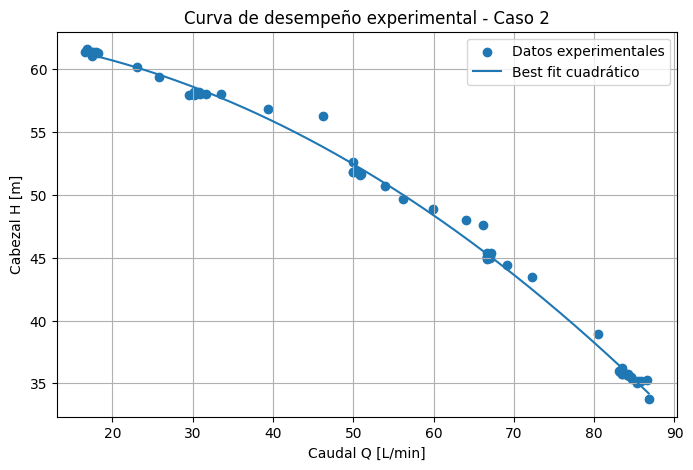

In [5]:
P_salida_bar = df_caso2["P_bar"]
P_salida_Pa_2 = P_salida_bar * 100000

Q_L_min_2 = df_caso2["Q_L_hr"] / 60

H_2 = P_salida_Pa_2 / (rho * g)

# Juntar datos en un DataFrame para limpiar y ordenar
datos_2 = pd.DataFrame({
    "Q_L_min": Q_L_min_2,
    "H_m": H_2
})

datos_2 = datos_2.dropna()
datos_2 = datos_2.sort_values("Q_L_min")

Q_2 = datos_2["Q_L_min"].values
H_2 = datos_2["H_m"].values

# Best fit cuadrático: H = aQ^2 + bQ + c
coef_2 = np.polyfit(Q_2, H_2, 2)

a_2, b_2, c_2 = coef_2

print("Coeficientes caso 2:")
print(f"a = {a_2}")
print(f"b = {b_2}")
print(f"c = {c_2}")

print("\nEcuación ajustada:")
print(f"H(Q) = {a_2:.6f} Q^2 + {b_2:.6f} Q + {c_2:.6f}")

# Valores predichos por el ajuste
H_pred_2 = np.polyval(coef_2, Q_2)

# Cálculo de R2
SS_res = np.sum((H_2 - H_pred_2)**2)
SS_tot = np.sum((H_2 - np.mean(H_2))**2)

R2_2 = 1 - SS_res / SS_tot

print(f"R2 = {R2_2:.4f}")

# Curva suave para graficar
Q_fit_2 = np.linspace(Q_2.min(), Q_2.max(), 300)
H_fit_2 = np.polyval(coef_2, Q_fit_2)

plt.figure(figsize=(8,5))

plt.scatter(Q_2, H_2, label="Datos experimentales")
plt.plot(Q_fit_2, H_fit_2, label="Best fit cuadrático")

plt.xlabel("Caudal Q [L/min]")
plt.ylabel("Cabezal H [m]")
plt.title("Curva de desempeño experimental - Caso 2")
plt.grid(True)
plt.legend()
plt.show()

Coeficientes caso 3:
a = -0.00048808149388737367
b = -0.0066824909168814025
c = 31.18218534476498

Ecuación ajustada:
H(Q) = -0.000488 Q^2 + -0.006682 Q + 31.182185
R2 = 0.9876


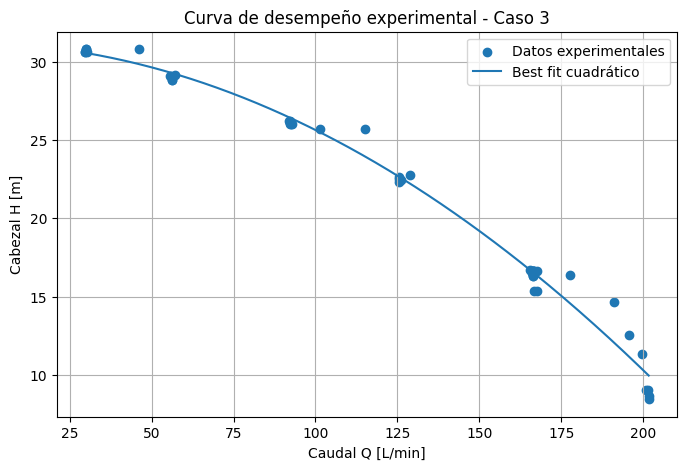

In [6]:
P_salida_bar = df_caso3["P_bar"]
P_salida_Pa_3 = P_salida_bar * 100000

Q_L_min_3 = df_caso3["Q_L_hr"] / 60

H_3 = P_salida_Pa_3 / (rho * g)

# Juntar datos en un DataFrame para limpiar y ordenar
datos_3 = pd.DataFrame({
    "Q_L_min": Q_L_min_3,
    "H_m": H_3
})

datos_3 = datos_3.dropna()
datos_3 = datos_3.sort_values("Q_L_min")

Q_3 = datos_3["Q_L_min"].values
H_3 = datos_3["H_m"].values

# Best fit cuadrático: H = aQ^2 + bQ + c
coef_3 = np.polyfit(Q_3, H_3, 2)

a_3, b_3, c_3 = coef_3

print("Coeficientes caso 3:")
print(f"a = {a_3}")
print(f"b = {b_3}")
print(f"c = {c_3}")

print("\nEcuación ajustada:")
print(f"H(Q) = {a_3:.6f} Q^2 + {b_3:.6f} Q + {c_3:.6f}")

# Valores predichos por el ajuste
H_pred_3 = np.polyval(coef_3, Q_3)

# Cálculo de R2
SS_res = np.sum((H_3 - H_pred_3)**2)
SS_tot = np.sum((H_3 - np.mean(H_3))**2)

R2_3 = 1 - SS_res / SS_tot

print(f"R2 = {R2_3:.4f}")

# Curva suave para graficar
Q_fit_3 = np.linspace(Q_3.min(), Q_3.max(), 300)
H_fit_3 = np.polyval(coef_3, Q_fit_3)

plt.figure(figsize=(8,5))

plt.scatter(Q_3, H_3, label="Datos experimentales")
plt.plot(Q_fit_3, H_fit_3, label="Best fit cuadrático")

plt.xlabel("Caudal Q [L/min]")
plt.ylabel("Cabezal H [m]")
plt.title("Curva de desempeño experimental - Caso 3")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
df_datasheet = pd.read_csv("Datos del datasheet.csv", comment="#")

df_datasheet = df_datasheet.rename(columns={
    "Caudal (l/min)": "Q_L_min",
    "Altura (m)": "H_m"
})

df_datasheet = df_datasheet.dropna()
df_datasheet = df_datasheet.sort_values("Q_L_min")

Q_ds = df_datasheet["Q_L_min"].values
H_ds = df_datasheet["H_m"].values


coef_ds = np.polyfit(Q_ds, H_ds, 2)

a_ds, b_ds, c_ds = coef_ds

print("Coeficientes datasheet:")
print(f"a = {a_ds}")
print(f"b = {b_ds}")
print(f"c = {c_ds}")

print("\nEcuación datasheet ajustada:")
print(f"H(Q) = {a_ds:.6f} Q^2 + {b_ds:.6f} Q + {c_ds:.6f}")

H_pred_ds = np.polyval(coef_ds, Q_ds)

SS_res_ds = np.sum((H_ds - H_pred_ds)**2)
SS_tot_ds = np.sum((H_ds - np.mean(H_ds))**2)

R2_ds = 1 - SS_res_ds / SS_tot_ds

print(f"R2 datasheet = {R2_ds:.4f}")

Q_fit_ds = np.linspace(Q_ds.min(), Q_ds.max(), 300)
H_fit_ds = np.polyval(coef_ds, Q_fit_ds)

Coeficientes datasheet:
a = -0.0019214358682470678
b = -0.117079394543072
c = 33.84767686592998

Ecuación datasheet ajustada:
H(Q) = -0.001921 Q^2 + -0.117079 Q + 33.847677
R2 datasheet = 0.9981


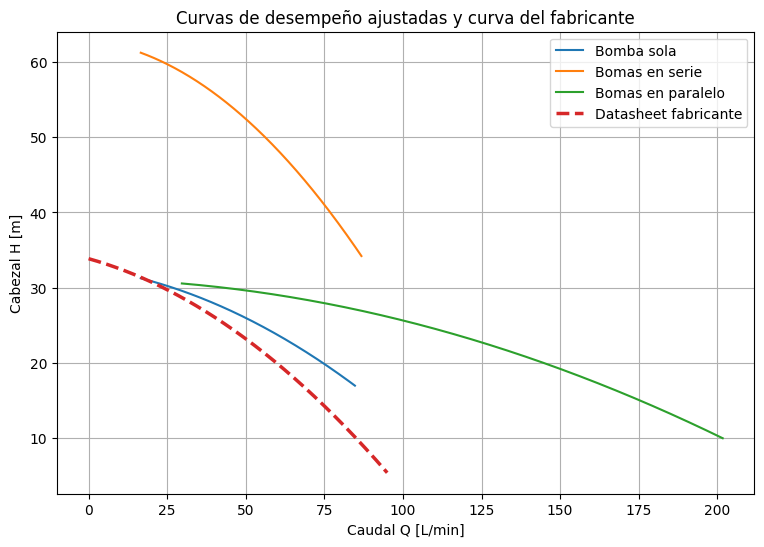

In [12]:
plt.figure(figsize=(9,6))

# Curvas suaves para cada caso experimental
Q_fit_1 = np.linspace(Q_1.min(), Q_1.max(), 300)
H_fit_1 = np.polyval(coef_1, Q_fit_1)

Q_fit_2 = np.linspace(Q_2.min(), Q_2.max(), 300)
H_fit_2 = np.polyval(coef_2, Q_fit_2)

Q_fit_3 = np.linspace(Q_3.min(), Q_3.max(), 300)
H_fit_3 = np.polyval(coef_3, Q_fit_3)

Q_fit_ds = np.linspace(Q_ds.min(), Q_ds.max(), 300)
H_fit_ds = np.polyval(coef_ds, Q_fit_ds)

# Graficar solo curvas
plt.plot(Q_fit_1, H_fit_1, label="Bomba sola")
plt.plot(Q_fit_2, H_fit_2, label="Bomas en serie")
plt.plot(Q_fit_3, H_fit_3, label="Bomas en paralelo")

# Curva del fabricante
plt.plot(Q_fit_ds, H_fit_ds, "--", linewidth=2.5, label="Datasheet fabricante")

plt.xlabel("Caudal Q [L/min]")
plt.ylabel("Cabezal H [m]")
plt.title("Curvas de desempeño ajustadas y curva del fabricante")
plt.grid(True)
plt.legend()
plt.show()

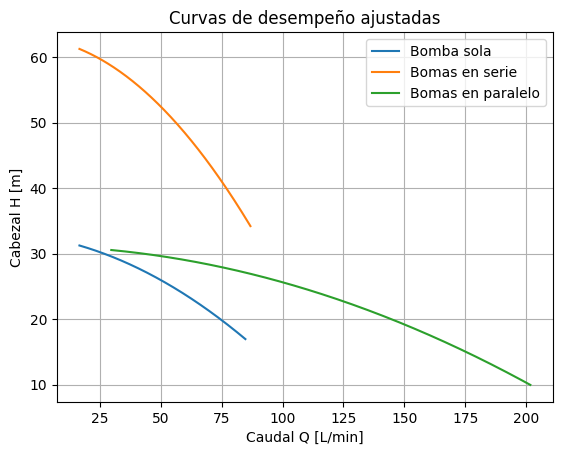

In [15]:
# Graficar solo las curvas
plt.plot(Q_fit_1, H_fit_1, label="Bomba sola")
plt.plot(Q_fit_2, H_fit_2, label="Bomas en serie")
plt.plot(Q_fit_3, H_fit_3, label="Bomas en paralelo")

plt.xlabel("Caudal Q [L/min]")
plt.ylabel("Cabezal H [m]")
plt.title("Curvas de desempeño ajustadas")
plt.grid(True)
plt.legend()
plt.show()